# 1. Setup and data loading

In [ ]:
import sys
import sklearn
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

np.random.seed(42)

# Plot settings
%matplotlib inline
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Load Data
diamonds = pd.read_csv("diamonds.csv")

if "Unnamed: 0" in diamonds.columns:
    diamonds = diamonds.drop("Unnamed: 0", axis=1)

print(diamonds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB
None


In [3]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
diamonds.corr(numeric_only=True)['price'].sort_values(ascending=False)

price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64

# 2. Preprocessing

## 2.1 Cleaning

In [5]:
# # 2.1 Cleaning: Check for invalid dimensions
print("Invalid dimensions (x, y, or z == 0):")

print(diamonds[(diamonds['x'] == 0) | (diamonds['y'] == 0) | (diamonds['z'] == 0)].shape)

# # Removing rows with invalid dimensions
diamonds = diamonds[(diamonds[['x', 'y', 'z']] != 0).all(axis=1)]

# # Rimuoviamo 'depth' perché ha correlazione irrilevante con il prezzo
# if 'depth' in diamonds.columns:
#     diamonds = diamonds.drop('depth', axis=1)
#     print("Colonna 'depth' rimossa.")
    
# # Creiamo il volume approssimativo
# diamonds['volume'] = diamonds['x'] * diamonds['y'] * diamonds['z']

# # Vediamo come correla il volume col prezzo
# print("Correlazione Volume-Prezzo:", diamonds['volume'].corr(diamonds['price']))

# # Ora possiamo rimuovere x, y, z perché 'volume' e 'carat' contengono già l'informazione
# diamonds = diamonds.drop(['x', 'y', 'z'], axis=1)
    
    


Invalid dimensions (x, y, or z == 0):
(20, 10)


## 2.2 Encoding Categorical Variables

In [ ]:
cut_mapping = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_mapping = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_mapping = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

diamonds['cut_enc'] = diamonds['cut'].map(cut_mapping)
diamonds['color_enc'] = diamonds['color'].map(color_mapping)
diamonds['clarity_enc'] = diamonds['clarity'].map(clarity_mapping)

diamonds_prepared = diamonds.drop(['cut', 'color', 'clarity'], axis=1)

In [7]:
diamonds_prepared.head()

,carat,depth,table,price,x,y,z,cut_enc,color_enc,clarity_enc
0,0.23,61.5,55.0,326,3.95,3.98,2.43,4,5,1
1,0.21,59.8,61.0,326,3.89,3.84,2.31,3,5,2
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1,5,4
3,0.29,62.4,58.0,334,4.20,4.23,2.63,3,1,3
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1,0,1


## 2.3 Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X = diamonds_prepared.drop("price", axis=1)
y = diamonds_prepared["price"]

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (43136, 9)
Test shape: (10784, 9)


## 2.4 Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Modeling

## 3.1 Lasso


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

X = diamonds_prepared.drop("price", axis=1) 
y = diamonds_prepared["price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=2.0, random_state=42) 
lasso.fit(X_scaled, y)

coeffs = pd.Series(lasso.coef_, index=X.columns)

print("--- Importanza delle Feature secondo Lasso ---")
print(coeffs.sort_values(key=abs, ascending=False))

print("\n--- Feature INUTILI (Coefficiente azzerato) ---")
print(coeffs[coeffs == 0].index.tolist())

--- Importanza delle Feature secondo Lasso ---
carat          5086.077625
x              -892.996151
clarity_enc     823.330231
color_enc       545.835657
cut_enc         133.888246
depth          -107.329025
z               -61.826498
table           -57.309996
y                 0.000000
dtype: float64

--- Feature INUTILI (Coefficiente azzerato) ---
['y']


### Rimozione valori inutili

In [ ]:
features_to_drop = ['y', 'depth']
X_train_sel = X_train.drop(features_to_drop, axis=1)
X_test_sel = X_test.drop(features_to_drop, axis=1)

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

print(f"Feature rimaste: {X_train_sel.columns.tolist()}")

Feature rimaste: ['carat', 'table', 'x', 'z', 'cut_enc', 'color_enc', 'clarity_enc']


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train_sel_scaled, y_train)

# Predizioni
y_pred_ridge = ridge_reg.predict(X_test_sel_scaled)

# Valutazione
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"Ridge Regression RMSE: {rmse_ridge:.2f}")
print(f"Ridge Regression R2: {r2_score(y_test, y_pred_ridge):.4f}")

Ridge Regression RMSE: 1210.71
Ridge Regression R2: 0.9086


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': [1.0, 'sqrt'] 
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_squared_error', 
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sel, y_train) 

best_rf = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 1.0, 'max_depth': 20}


In [14]:
# Predictions with the best model
y_pred_rf = best_rf.predict(X_test_sel)

# Metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Performance ---")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R^2 Score: {r2_rf:.4f}")



--- Random Forest Performance ---
RMSE: 535.58
MAE: 277.81
R^2 Score: 0.9821


Shap:

In [ ]:
import shap
X_sample = X_test_sel.iloc[:200]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_sample)

plt.figure(figsize=(10, 8))
plt.title("Feature Importance (SHAP) - Calcolato su 200 esempi")
shap.summary_plot(shap_values, X_sample, show=False)
plt.show()



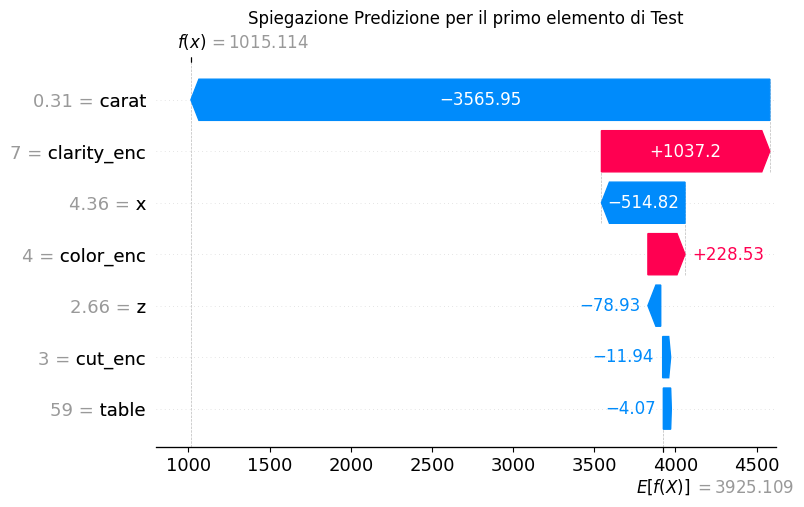

In [16]:
plt.figure()
plt.title("Spiegazione Predizione per il primo elemento di Test")
shap.plots.waterfall(shap_values[0], show=False)
plt.show()

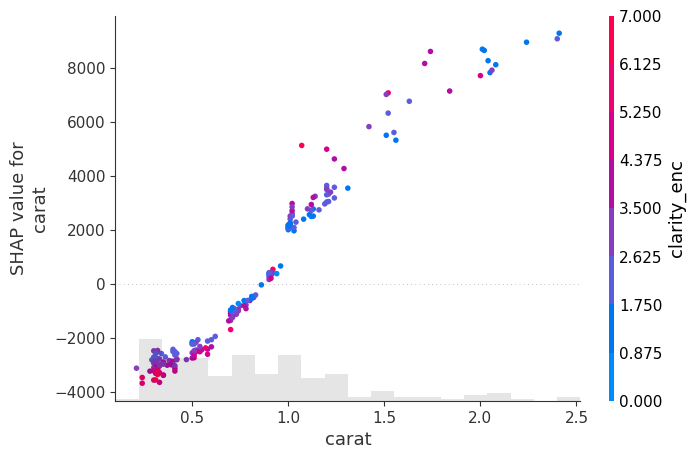

In [ ]:
top_feature = X_test_sel.columns[0] 
shap.plots.scatter(shap_values[:, top_feature], color=shap_values)

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Define features
numeric_cols = ['carat', 'table','x', 'z'] 
categorical_cols = ['cut', 'color', 'clarity']

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_cols)
])
# Assuming we pass encoded categoricals, or we could handle raw categoricals here with OrdinalEncoder

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42))
])

X_raw = diamonds.drop("price", axis=1) 
y_raw = diamonds["price"]
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

pipeline.fit(X_train_raw, y_train_raw)
print(f"Pipeline R2 Score (End-to-End): {pipeline.score(X_test_raw, y_test_raw):.4f}")

Pipeline R2 Score (End-to-End): 0.9818
